In [2]:
import importlib.metadata as metadata
from packaging.version import Version, InvalidVersion

MIN_PROTOBUF = Version("5.28.0")
MAX_PROTOBUF = Version("6.0.0")

try:
    current_version = Version(metadata.version("protobuf"))
    print(f"Current protobuf version: {current_version}")
except metadata.PackageNotFoundError as exc:
    raise RuntimeError(
        "protobuf is missing; install protobuf>=5.28.0,<6.0.0 from a terminal before running this notebook."
    ) from exc
except InvalidVersion as exc:
    raise RuntimeError("Detected invalid protobuf version; reinstall protobuf.") from exc

if not (MIN_PROTOBUF <= current_version < MAX_PROTOBUF):
    raise RuntimeError(
        "Detected protobuf version incompatible with TensorFlow (need >=5.28.0 and <6.0.0). "
        "Run `pip install \"protobuf>=5.28.0,<6.0.0\"` in a terminal, then restart the kernel."
    )

print("protobuf requirement satisfied. Proceeding without restarting the kernel.")

Current protobuf version: 5.28.3
protobuf requirement satisfied. Proceeding without restarting the kernel.


In [3]:
import os
import random
import shutil
from glob import glob

import numpy as np
import cv2
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import confusion_matrix, classification_report
import itertools

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)


C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [4]:
# Paths
workspace_dir = os.getcwd()
base_dir = os.path.join(workspace_dir, "betel_dataset")

train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

required_dirs = [train_dir, val_dir, test_dir]
for d in required_dirs:
    if not os.path.isdir(d):
        raise FileNotFoundError(f"Expected directory not found: {d}")

classes = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
print("Classes:", classes)

print("✅ Found locally prepared dataset; skipping split/copy stage.")


Classes: ['Anthracnose', 'Healthy_Leaf', 'Leaf_Rot', 'Leaf_Spot', 'bacterial_leaf']
✅ Found locally prepared dataset; skipping split/copy stage.


In [5]:
def gabor_enhance(rgb_img):
    """
    rgb_img: (H, W, 3), float32 or uint8, values 0-255, RGB
    Output: enhanced float32 image, still RGB (H, W, 3)
    """
    rgb = rgb_img.astype(np.float32)
    
    # Convert to grayscale for Gabor
    gray = cv2.cvtColor(rgb_img.astype(np.uint8), cv2.COLOR_RGB2GRAY)

    # Multi-orientation Gabor filters
    gabor_sum = np.zeros_like(gray, dtype=np.float32)
    thetas = [0, np.pi/4, np.pi/2, 3*np.pi/4]

    for theta in thetas:
        kernel = cv2.getGaborKernel(
            ksize=(21, 21),
            sigma=5.0,
            theta=theta,
            lambd=10.0,
            gamma=0.5,
            psi=0
        )
        filtered = cv2.filter2D(gray, cv2.CV_32F, kernel)
        gabor_sum += filtered

    # Normalize Gabor result to 0–255
    gabor_norm = cv2.normalize(gabor_sum, None, 0, 255, cv2.NORM_MINMAX)
    gabor_3ch = np.stack([gabor_norm]*3, axis=-1)

    # Combine: keep color + add texture emphasis
    combined = 0.7 * rgb + 0.3 * gabor_3ch
    combined = np.clip(combined, 0, 255)

    return combined.astype(np.float32)

def preprocess_for_resnet(img):
    """
    This function will be used by ImageDataGenerator.
    Steps:
    - Apply Gabor enhancement
    - Apply ResNet50 preprocess_input (scales to [-1,1])
    """
    enhanced = gabor_enhance(img)
    return preprocess_input(enhanced)  # ResNet50-specific normalization


In [6]:
IMG_SIZE   = 224
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest',
    preprocessing_function=preprocess_for_resnet
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_for_resnet
)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_gen = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_indices = train_gen.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}
print("Class indices:", class_indices)


Found 1639 images belonging to 5 classes.
Found 507 images belonging to 5 classes.
Found 499 images belonging to 5 classes.
Class indices: {'Anthracnose': 0, 'Healthy_Leaf': 1, 'Leaf_Rot': 2, 'Leaf_Spot': 3, 'bacterial_leaf': 4}


In [7]:
MODEL_PATH = os.path.join(workspace_dir, "resnet50_betel_gabor.h5")
if not os.path.isfile(MODEL_PATH):
    raise FileNotFoundError(f"Pretrained model weights not found at: {MODEL_PATH}")

print(f"Loading pretrained model from {MODEL_PATH}")
model = tf.keras.models.load_model(MODEL_PATH)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

num_classes = len(class_indices)
model.summary()


Loading pretrained model from d:\Edu\sem\proposed\kaggle\working\resnet50_betel_gabor.h5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,769,413 (94.49 MB)

 Trainable params: 16,159,749 (61.64 MB)

 Non-trainable params: 8,609,664 (32.84 MB)

In [8]:
print("Training step skipped. Using pretrained weights for evaluation only.")


Training step skipped. Using pretrained weights for evaluation only.


In [9]:
# Evaluate
test_loss, test_acc = model.evaluate(test_gen)
print(f"✅ Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

# Predictions
y_prob = model.predict(test_gen)
y_pred = np.argmax(y_prob, axis=1)
y_true = test_gen.classes

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=[idx_to_class[i] for i in range(num_classes)]))

cm = confusion_matrix(y_true, y_pred)
cm


32/32 ━━━━━━━━━━━━━━━━━━━━ 33s 931ms/step - accuracy: 0.9860 - loss: 0.0562
✅ Test Accuracy: 0.9860, Test Loss: 0.0562
32/32 ━━━━━━━━━━━━━━━━━━━━ 30s 877ms/step
Classification Report:
                precision    recall  f1-score   support

   Anthracnose       1.00      1.00      1.00       101
  Healthy_Leaf       0.98      0.97      0.98       102
      Leaf_Rot       0.99      0.98      0.98        98
     Leaf_Spot       0.96      0.98      0.97       100
bacterial_leaf       1.00      1.00      1.00        98

      accuracy                           0.99       499
     macro avg       0.99      0.99      0.99       499
  weighted avg       0.99      0.99      0.99       499



array([[101,   0,   0,   0,   0],
       [  0,  99,   0,   3,   0],
       [  0,   1,  96,   1,   0],
       [  0,   1,   1,  98,   0],
       [  0,   0,   0,   0,  98]])

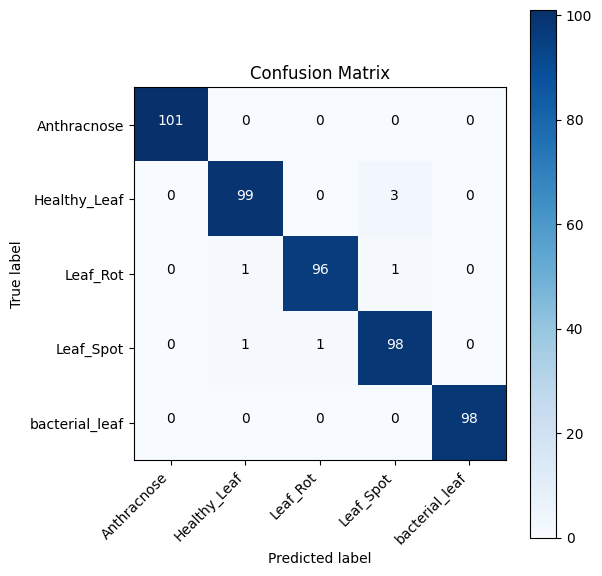

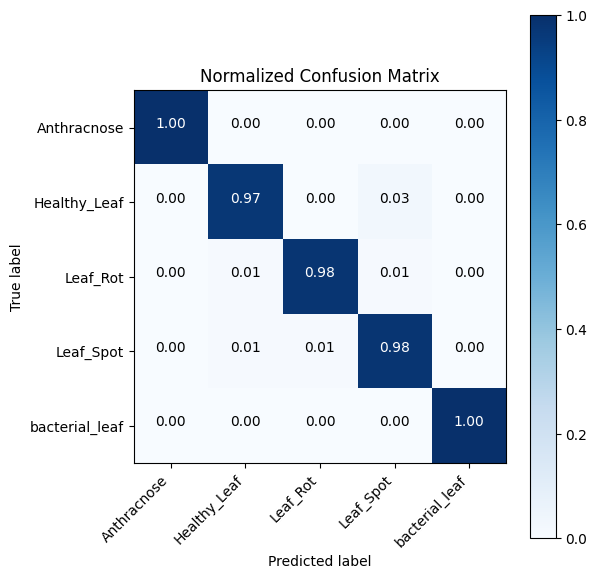

In [10]:
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix'):
    if normalize:
        cm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-8)

    plt.figure(figsize=(6, 6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, ha='right')
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

class_names = [idx_to_class[i] for i in range(num_classes)]
plot_confusion_matrix(cm, class_names, title="Confusion Matrix")
plot_confusion_matrix(cm, class_names, normalize=True, title="Normalized Confusion Matrix")


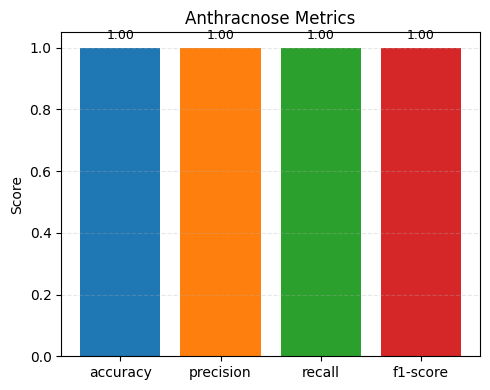

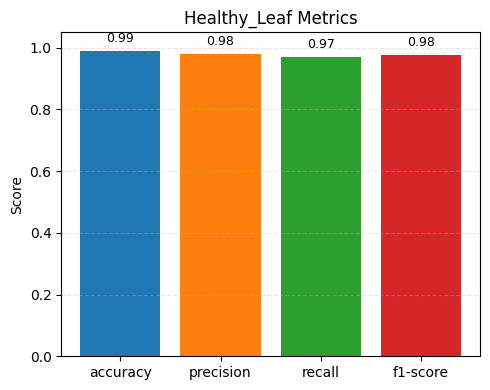

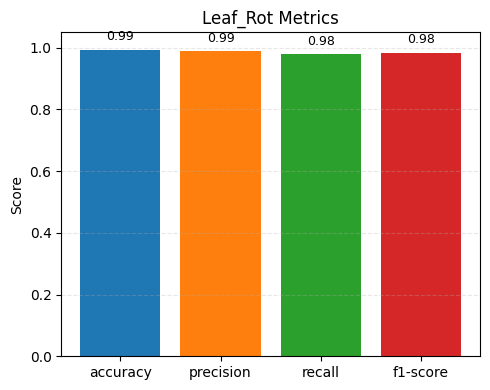

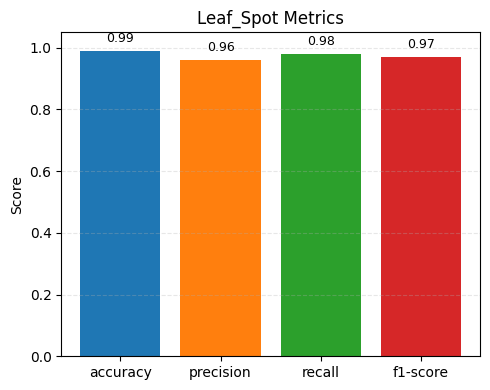

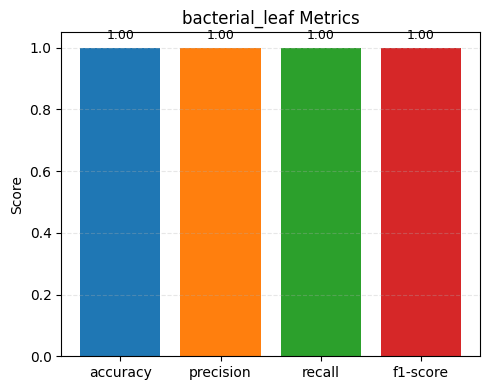

In [12]:
# Plot per-class Accuracy, Precision, Recall, and F1
metrics_report = classification_report(
    y_true,
    y_pred,
    labels=list(range(num_classes)),
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

cm = np.asarray(cm)
total_samples = cm.sum()
per_class_metrics = {}

for idx, cls_name in enumerate(class_names):
    tp = cm[idx, idx]
    fn = np.sum(cm[idx, :]) - tp
    fp = np.sum(cm[:, idx]) - tp
    tn = total_samples - (tp + fp + fn)
    acc = (tp + tn) / total_samples if total_samples else 0.0
    class_stats = metrics_report.get(cls_name, {})

    per_class_metrics[cls_name] = {
        "accuracy": acc,
        "precision": class_stats.get("precision", 0.0),
        "recall": class_stats.get("recall", 0.0),
        "f1-score": class_stats.get("f1-score", 0.0),
    }

metric_labels = ["accuracy", "precision", "recall", "f1-score"]
bar_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

plt.close('all')
for cls_name in class_names:
    values = [per_class_metrics[cls_name][m] for m in metric_labels]
    fig, ax = plt.subplots(figsize=(5, 4))
    bars = ax.bar(metric_labels, values, color=bar_colors)
    ax.set_ylim(0, 1.05)
    ax.set_title(f"{cls_name} Metrics")
    ax.set_ylabel("Score")
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02, f"{val:.2f}", ha="center", va="bottom", fontsize=9)
    fig.tight_layout()
    plt.show()

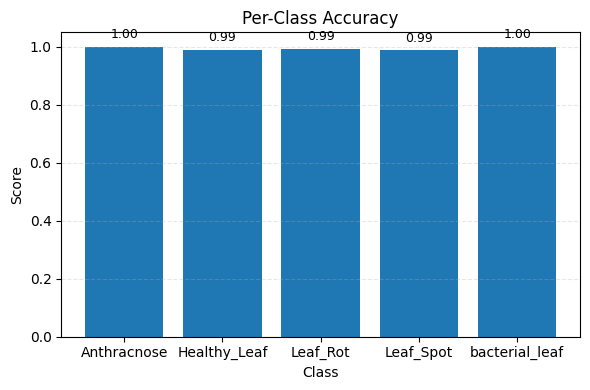

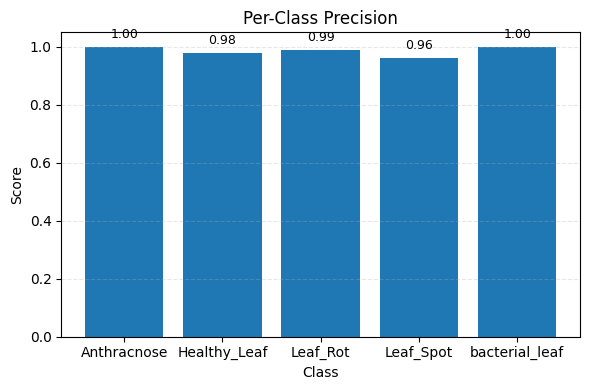

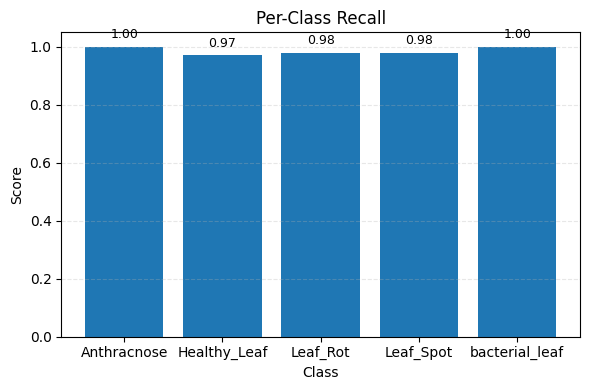

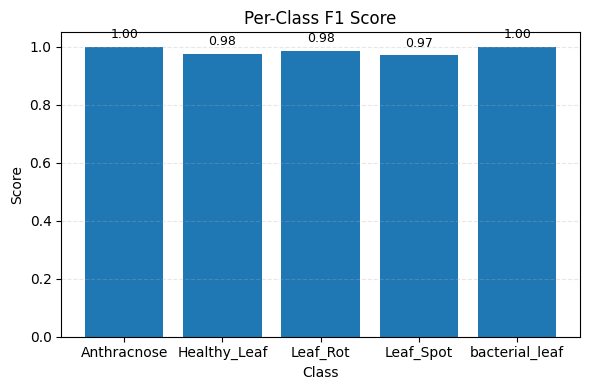

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# Classification report
metrics_report = classification_report(
    y_true,
    y_pred,
    labels=list(range(num_classes)),
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

cm = np.asarray(cm)
total_samples = cm.sum()

# Store metrics
per_class_metrics = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": []
}

# Calculate metrics
for idx, cls_name in enumerate(class_names):
    tp = cm[idx, idx]
    fn = np.sum(cm[idx, :]) - tp
    fp = np.sum(cm[:, idx]) - tp
    tn = total_samples - (tp + fp + fn)

    acc = (tp + tn) / total_samples if total_samples else 0.0
    class_stats = metrics_report.get(cls_name, {})

    per_class_metrics["accuracy"].append(acc)
    per_class_metrics["precision"].append(class_stats.get("precision", 0.0))
    per_class_metrics["recall"].append(class_stats.get("recall", 0.0))
    per_class_metrics["f1"].append(class_stats.get("f1-score", 0.0))

# Plot settings
metric_titles = {
    "accuracy": "Per-Class Accuracy",
    "precision": "Per-Class Precision",
    "recall": "Per-Class Recall",
    "f1": "Per-Class F1 Score"
}

plt.close("all")

# Separate plot for each metric
for metric, values in per_class_metrics.items():
    plt.figure(figsize=(6, 4))
    bars = plt.bar(class_names, values)
    plt.ylim(0, 1.05)
    plt.title(metric_titles[metric])
    plt.ylabel("Score")
    plt.xlabel("Class")
    plt.grid(axis="y", linestyle="--", alpha=0.3)

    # Value labels
    for bar, val in zip(bars, values):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            val + 0.02,
            f"{val:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.tight_layout()
    plt.show()


In [18]:
def preprocess_single_image(img_path, img_size=IMG_SIZE):
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Could not read image: {img_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (img_size, img_size))

    x = preprocess_for_resnet(img)
    x = np.expand_dims(x, axis=0)
    return x

def predict_image(img_path):
    x = preprocess_single_image(img_path)
    preds = model.predict(x)
    cls_idx = np.argmax(preds)
    cls_name = idx_to_class[cls_idx]
    confidence = preds[0][cls_idx]
    print(f"Predicted class: {cls_name} (confidence: {confidence:.4f})")
    return cls_name, confidence

sample_images = glob(os.path.join(test_dir, "*", "*"))
if not sample_images:
    raise ValueError("No images found in test directory.")

test_img_path = r'D:\Edu\sem\proposed\kaggle\working\betel_dataset\test\Healthy_Leaf\CA_OR_0011.jpg'
print(f"Sample image: {test_img_path}")
predict_image(test_img_path)


Sample image: D:\Edu\sem\proposed\kaggle\working\betel_dataset\test\Healthy_Leaf\CA_OR_0011.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
Predicted class: Healthy_Leaf (confidence: 1.0000)


('Healthy_Leaf', np.float32(0.99999785))

In [16]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

try:
    import pandas as pd
except ImportError:
    pd = None


def _render_ascii_table(headers, rows):
    """Fallback ASCII table printer if pandas is unavailable."""
    widths = [len(h) for h in headers]
    for row in rows:
        for idx, value in enumerate(row):
            widths[idx] = max(widths[idx], len(value))

    def fmt(row):
        return " | ".join(val.ljust(widths[idx]) for idx, val in enumerate(row))

    divider = "-+-".join("-" * w for w in widths)
    print(fmt(headers))
    print(divider)
    for row in rows:
        print(fmt(row))


# Ensure required tensors exist (recompute if notebook was restarted)
if "y_true" not in globals() or "y_pred" not in globals():
    if "model" not in globals() or "test_gen" not in globals():
        raise RuntimeError(
            "Missing model/test_gen; run the evaluation cell before generating the metrics table."
        )
    y_prob = model.predict(test_gen)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = test_gen.classes

if "cm" not in globals():
    cm = confusion_matrix(y_true, y_pred)

if "class_names" not in globals():
    if "idx_to_class" not in globals() or "num_classes" not in globals():
        raise RuntimeError(
            "Class names not available; rerun the data generator setup cell to rebuild idx_to_class."
        )
    class_names = [idx_to_class[i] for i in range(num_classes)]

# Summarize per-class accuracy/precision/recall/F1 in a table
metrics_report = classification_report(
    y_true,
    y_pred,
    labels=list(range(len(class_names))),
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

cm = np.asarray(cm)
total_samples = cm.sum()

rows_for_display = []
for idx, cls_name in enumerate(class_names):
    tp = cm[idx, idx]
    fn = np.sum(cm[idx, :]) - tp
    fp = np.sum(cm[:, idx]) - tp
    tn = total_samples - (tp + fp + fn)

    acc = (tp + tn) / total_samples if total_samples else 0.0
    class_stats = metrics_report.get(cls_name, {})

    rows_for_display.append(
        {
            "class": cls_name,
            "accuracy": acc,
            "precision": class_stats.get("precision", 0.0),
            "recall": class_stats.get("recall", 0.0),
            "f1": class_stats.get("f1-score", 0.0),
            "support": int(class_stats.get("support", 0)),
        }
    )

headers = ["Class", "Accuracy", "Precision", "Recall", "F1", "Support"]
render_ready_rows = [
    [
        row["class"],
        f"{row['accuracy']:.3f}",
        f"{row['precision']:.3f}",
        f"{row['recall']:.3f}",
        f"{row['f1']:.3f}",
        str(row['support']),
    ]
    for row in rows_for_display
]

if pd is not None:
    per_class_df = pd.DataFrame(rows_for_display).set_index("class")
    display(per_class_df.round(3))
else:
    print("pandas not available; falling back to plain-text table.")
    _render_ascii_table(headers, render_ready_rows)

,accuracy,precision,recall,f1,support
class,,,,,
Anthracnose,1.000,1.000,1.000,1.000,101
Healthy_Leaf,0.990,0.980,0.971,0.975,102
Leaf_Rot,0.994,0.990,0.980,0.985,98
Leaf_Spot,0.988,0.961,0.980,0.970,100
bacterial_leaf,1.000,1.000,1.000,1.000,98


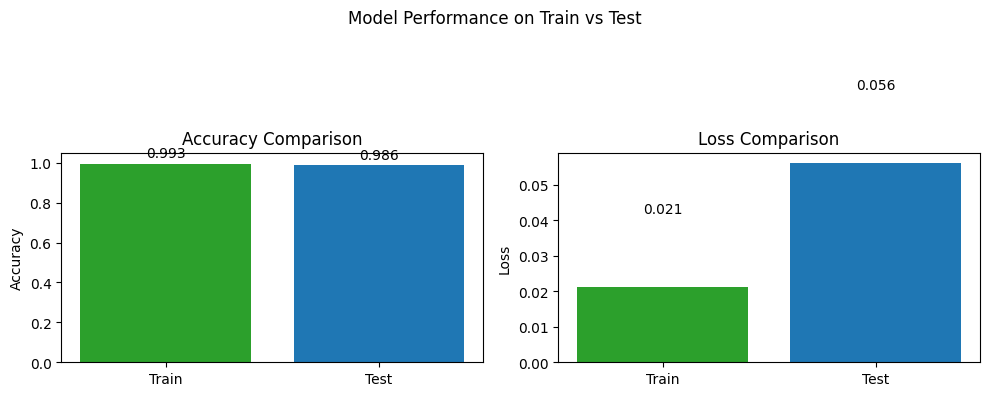

Train Accuracy: 0.9927, Train Loss: 0.0212
Test Accuracy:  0.9860, Test Loss:  0.0562


In [17]:
import matplotlib.pyplot as plt

# Ensure necessary objects exist
required_symbols = ["model", "train_gen", "test_gen"]
missing = [name for name in required_symbols if name not in globals()]
if missing:
    raise RuntimeError(
        f"Missing objects {missing}; run the earlier setup/evaluation cells before plotting accuracy graphs."
    )

# Evaluate on train and test generators (silent)
train_gen.reset()
train_loss, train_acc = model.evaluate(train_gen, verbose=0)

test_gen.reset()
test_loss, test_acc = model.evaluate(test_gen, verbose=0)

# Plot accuracy and loss comparisons
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sets = ["Train", "Test"]
acc_values = [train_acc, test_acc]
loss_values = [train_loss, test_loss]
colors = ["#2ca02c", "#1f77b4"]

axes[0].bar(sets, acc_values, color=colors)
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Accuracy Comparison")
axes[0].set_ylabel("Accuracy")
for idx, val in enumerate(acc_values):
    axes[0].text(idx, val + 0.02, f"{val:.3f}", ha="center", va="bottom")

axes[1].bar(sets, loss_values, color=colors)
axes[1].set_title("Loss Comparison")
axes[1].set_ylabel("Loss")
for idx, val in enumerate(loss_values):
    axes[1].text(idx, val + 0.02, f"{val:.3f}", ha="center", va="bottom")

fig.suptitle("Model Performance on Train vs Test")
fig.tight_layout()
plt.show()

print(f"Train Accuracy: {train_acc:.4f}, Train Loss: {train_loss:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}, Test Loss:  {test_loss:.4f}")

In [ ]:
import os
import textwrap
from pathlib import Path

workspace_dir = globals().get("workspace_dir")
if workspace_dir is None:
    workspace_dir = str(Path.cwd())

streamlit_app_path = os.path.join(workspace_dir, "betel_streamlit_app.py")
streamlit_app_code = textwrap.dedent('''
    """Streamlit UI for Betel leaf disease classification."""
    import io
    import os
    from pathlib import Path

    import cv2
    import numpy as np
    import pandas as pd
    import streamlit as st
    import tensorflow as tf
    from PIL import Image
    from tensorflow.keras.applications.resnet50 import preprocess_input

    IMG_SIZE = 224

    BASE_DIR = Path(__file__).resolve().parent
    MODEL_PATH = BASE_DIR / "resnet50_betel_gabor.h5"
    DATASET_DIR = BASE_DIR / "betel_dataset"
    TRAIN_DIR = DATASET_DIR / "train"
    TEST_DIR = DATASET_DIR / "test"

    def infer_class_names():
        if TRAIN_DIR.is_dir():
            return sorted([p.name for p in TRAIN_DIR.iterdir() if p.is_dir()])
        if TEST_DIR.is_dir():
            return sorted({p.parent.name for p in TEST_DIR.rglob("*") if p.is_file()})
        return []

    CLASS_NAMES = infer_class_names()

    def list_dataset_images():
        if not TEST_DIR.is_dir():
            return []
        return sorted([str(p) for p in TEST_DIR.glob("*/*") if p.is_file()])

    @st.cache_resource(show_spinner=False)
    def load_classifier():
        if not MODEL_PATH.exists():
            raise FileNotFoundError(f"Model weights not found at {MODEL_PATH}")
        model = tf.keras.models.load_model(MODEL_PATH)
        return model

    def gabor_enhance(rgb_img):
        rgb = rgb_img.astype(np.float32)
        gray = cv2.cvtColor(rgb_img.astype(np.uint8), cv2.COLOR_RGB2GRAY)
        gabor_sum = np.zeros_like(gray, dtype=np.float32)
        for theta in (0, np.pi / 4, np.pi / 2, 3 * np.pi / 4):
            kernel = cv2.getGaborKernel((21, 21), 5.0, theta, 10.0, 0.5, 0)
            gabor_sum += cv2.filter2D(gray, cv2.CV_32F, kernel)
        gabor_norm = cv2.normalize(gabor_sum, None, 0, 255, cv2.NORM_MINMAX)
        gabor_3ch = np.stack([gabor_norm] * 3, axis=-1)
        combined = np.clip(0.7 * rgb + 0.3 * gabor_3ch, 0, 255)
        return combined.astype(np.float32)

    def prepare_tensor(rgb_img):
        resized = cv2.resize(rgb_img, (IMG_SIZE, IMG_SIZE))
        enhanced = gabor_enhance(resized)
        processed = preprocess_input(enhanced)
        return np.expand_dims(processed, axis=0)

    def predict_probabilities(rgb_img):
        model = load_classifier()
        tensor = prepare_tensor(rgb_img)
        probs = model.predict(tensor, verbose=0)[0]
        return probs

    def main():
        st.set_page_config(page_title="Betel Leaf Disease Classifier", layout="centered")
        st.title("Betel Leaf Disease Classifier")
        st.caption("Select a prepared sample or upload your own image to see the predicted disease class.")

        dataset_images = list_dataset_images()
        source_choice = st.radio(
            "Choose image source",
            ("Dataset sample", "Upload your own"),
            horizontal=True,
        )

        rgb_image = None
        source_label = ""

        if source_choice == "Dataset sample":
            if not dataset_images:
                st.info("No images found under betel_dataset/test. Add files to use this option.")
            else:
                rel_map = {
                    os.path.relpath(path, BASE_DIR): path
                    for path in dataset_images
                }
                rel_keys = sorted(rel_map.keys())
                selected_rel = st.selectbox("Select an image", rel_keys)
                selected_path = rel_map[selected_rel]
                bgr_img = cv2.imread(selected_path)
                if bgr_img is None:
                    st.error(f"Unable to read image: {selected_rel}")
                else:
                    rgb_image = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)
                    source_label = selected_rel
        else:
            uploaded = st.file_uploader(
                "Upload a leaf image",
                type=["jpg", "jpeg", "png", "bmp", "tif", "tiff"],
            )
            if uploaded is not None:
                bytes_data = uploaded.read()
                try:
                    pil_img = Image.open(io.BytesIO(bytes_data)).convert("RGB")
                    rgb_image = np.array(pil_img)
                    source_label = uploaded.name or "Uploaded image"
                except Exception as exc:
                    st.error(f"Could not load the uploaded image: {exc}")

        if rgb_image is None:
            st.stop()

        st.image(rgb_image, caption=source_label or "Selected image", use_column_width=True)

        with st.spinner("Running inference..."):
            probs = predict_probabilities(rgb_image)

        label_names = CLASS_NAMES if CLASS_NAMES else [f"Class {idx}" for idx in range(len(probs))]
        pred_idx = int(np.argmax(probs))
        pred_class = label_names[pred_idx]
        pred_conf = float(probs[pred_idx]) * 100.0

        st.success(f"Prediction: {pred_class} ({pred_conf:.2f}%)")

        probs_df = pd.DataFrame(
            {"Class": label_names, "Probability": probs}
        ).sort_values("Probability", ascending=False)

        st.bar_chart(probs_df.set_index("Class"))
        st.dataframe(probs_df.style.format({"Probability": "{:.2%}"}), use_container_width=True)

        st.caption(
            "Tip: run `streamlit run betel_streamlit_app.py` from this folder to launch the UI."
        )

    if __name__ == "__main__":
        main()
''')

with open(streamlit_app_path, "w", encoding="utf-8") as streamlit_file:
    streamlit_file.write(streamlit_app_code.strip() + "\n")

print(f"✅ Streamlit app saved to: {streamlit_app_path}")
print("Launch it from a terminal with: streamlit run betel_streamlit_app.py")

✅ Streamlit app saved to: d:\Edu\SEM 7\proposed\kaggle\working\betel_streamlit_app.py
Launch it from a terminal with: streamlit run betel_streamlit_app.py
